In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from sklearn.metrics import r2_score

# ─────────────────────────────────────────────────────────────
# MATPLOTLIB STYLE
# ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.facecolor": "#0d1117", "figure.facecolor": "#0d1117",
    "axes.edgecolor": "#30363d", "axes.labelcolor": "#e6edf3",
    "xtick.color": "#8b949e",   "ytick.color": "#8b949e",
    "text.color": "#e6edf3",    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d", "axes.titlecolor": "#e6edf3",
    "grid.color": "#21262d",    "grid.alpha": 0.5,
})
CMAP_FS   = "RdYlGn"
C_BLUE    = "#58a6ff"; C_GREEN = "#3fb950"; C_YELLOW = "#d29922"
C_RED     = "#f85149"; C_PURPLE= "#bc8cff"; C_CYAN   = "#39d353"

# ─────────────────────────────────────────────────────────────
# DEVICE
# ─────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# =========================================================
# ██ REFERENCE SCALES — Non-Dimensionalization
# =========================================================
# [S1] All PDEs are solved in dimensionless (barred) variables:
#   x̄ = x / L_ref,   z̄ = z / L_ref,   t̄ = t / T_ref
#   h̄ = h / H_ref,   ū = u / U_ref
#   σ̄ = σ / P_ref
#
# With L_ref = Z_MAX, T_ref = T_MAX, P_ref = 1e5 Pa, H_ref = Z_MAX,
# U_ref = 1e-3 m all dimensionless residuals become O(1).
# =========================================================
L_REF  = 10.0          # [m]      length scale = Z_MAX
P_REF  = 1e5           # [Pa]     stress / pressure scale
H_REF  = L_REF         # [m]      head scale (≈ P_ref / γw_dim)
U_REF  = 1e-3          # [m]      displacement scale
RHO_W  = 1000.0        # [kg/m³]
G_DIM  = 9.81          # [m/s²]   dimensional gravity
GAMMA_W_DIM = G_DIM * RHO_W   # 9810 N/m³

# Dimensionless gravity and water unit weight
# γ̄w = γw_dim * H_ref / P_ref
GAMMA_W_ND = GAMMA_W_DIM * H_REF / P_REF   # ≈ 0.981

# Slope angle
SLOPE_ANGLE_DEG = 20.0
BETA = np.radians(SLOPE_ANGLE_DEG)
# Dimensionless body force: ρ̄·ḡ = ρ·g·L_ref / P_ref
# Computed per layer after rho_s defined

FS_THRESHOLD = 1.2

# ─────────────────────────────────────────────────────────────
# TRAINING SCHEDULE
# ─────────────────────────────────────────────────────────────
N_COLLOC  = 1500
N_BC      = 300
N_IC      = 600
WARMUP_EPOCHS = 500
PHASE1_END    = 100     # data + IC only
PHASE2_END    = 500     # + physics (ramping weight)
PHASE3_END    = 1000    # full training
LBFGS_STEPS   = 200      # L-BFGS fine-tuning at end
LR_MAX   = 1e-3
LR_MIN   = 1e-6

# ─────────────────────────────────────────────────────────────
# DOMAIN
# ─────────────────────────────────────────────────────────────
X_MAX_DIM = 50.0         # [m] dimensional
Z_MAX_DIM = 10.0         # [m] dimensional
# In normalised coords: x ∈ [0,5], z ∈ [0,1]
X_MAX_ND  = X_MAX_DIM / L_REF   # = 5.0
Z_MAX_ND  = Z_MAX_DIM / L_REF   # = 1.0

# ─────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────
sensor_df = pd.read_csv("/content/label_109_EMA_optimized_PINN.csv")

# [FIX-1] Verify these are TRUE spatial coordinates in metres!
X_COL, Z_COL = "temp", "geo"

# Load dimensional coordinates → convert to dimensionless
x_data_nd = torch.tensor(sensor_df[X_COL].values / L_REF,
                          device=device, dtype=torch.float32).unsqueeze(1)
z_data_nd = torch.tensor(sensor_df[Z_COL].values / L_REF,
                          device=device, dtype=torch.float32).unsqueeze(1)

sensor_df["timestamp"] = pd.to_datetime(sensor_df["timestamp"])
t_sec = (sensor_df["timestamp"] - sensor_df["timestamp"].min()).dt.total_seconds()
T_REF = float(t_sec.max())     # time scale = total duration [s]

t_data_nd = torch.tensor(t_sec.values / T_REF,
                          device=device, dtype=torch.float32).unsqueeze(1)
theta_data = torch.tensor(sensor_df["soil"].values,
                           device=device, dtype=torch.float32).unsqueeze(1)

print(f"Dataset: {len(sensor_df)} points | T_ref={T_REF:.0f}s "
      f"| x∈[{x_data_nd.min():.2f},{x_data_nd.max():.2f}] "
      f"| z∈[{z_data_nd.min():.2f},{z_data_nd.max():.2f}]")

# Rainfall (real or synthetic)
HAS_RAIN = "rainfall" in sensor_df.columns
if HAS_RAIN:
    _t_rain = t_sec.values.astype(np.float32) / T_REF
    _q_rain = sensor_df["rainfall"].values.astype(np.float32)   # [m/s]

def rainfall_nd(t_nd):
    """Rainfall intensity [m/s] — returns tensor shape [N,1]."""
    if HAS_RAIN:
        t_np = t_nd.detach().cpu().numpy().flatten()
        q    = np.interp(t_np, _t_rain, _q_rain)
        return torch.tensor(q, device=device, dtype=torch.float32).unsqueeze(1)
    # Synthetic two-peak storm
    p1, p2 = 0.33, 0.67
    s      = 0.05
    q = 1.39e-6 * (torch.exp(-0.5*((t_nd-p1)/s)**2) +
                   torch.exp(-0.5*((t_nd-p2)/s)**2))
    return q.clamp(min=0.0)

# =========================================================
# ██ SOIL LAYERS (in dimensionless z)
# =========================================================
Z_L1 = 2.0 / L_REF   # = 0.2  (0–2m → Sandy Clay Loam)
Z_L2 = 6.0 / L_REF   # = 0.6  (2–6m → Clay Loam)
# Layer 3: 6–10m → Clay

def soil_layer(z_nd):
    """Layer index tensor from dimensionless z."""
    return torch.where(z_nd < Z_L1,
           torch.zeros_like(z_nd, dtype=torch.long),
           torch.where(z_nd < Z_L2,
           torch.ones_like(z_nd, dtype=torch.long),
           2 * torch.ones_like(z_nd, dtype=torch.long)))

# =========================================================
# ██ MATERIAL PARAMETERS — [S1] Pre-scaled to dimensionless
# =========================================================
# ── Elastic ──────────────────────────────────────────────
E_ND  = torch.tensor([20e6, 10e6, 500e6], device=device) / P_REF
# E_ND = [200, 100, 5000]  ← all O(1e2–1e3), safe for PINN
nu    = torch.tensor([0.30, 0.35, 0.25], device=device)

# ── Strength (Mohr-Coulomb) ──────────────────────────────
phi_deg = torch.tensor([30.0, 25.0, 40.0], device=device)
phi_rad_t = phi_deg * np.pi / 180.0
c_ND    = torch.tensor([15e3, 25e3, 200e3], device=device) / P_REF
# c_ND = [0.15, 0.25, 2.0]  ← O(1), safe

# ── Density → dimensionless body force ───────────────────
rho_s_dim = torch.tensor([1700.0, 1800.0, 2200.0], device=device)
# ρ̄ = ρ·g·L_ref / P_ref
rho_ND  = rho_s_dim * G_DIM * L_REF / P_REF
# rho_ND ≈ [1.67, 1.77, 2.16]  ← O(1), safe

# Dimensionless body forces
BF_PARALLEL_ND = rho_ND * float(np.sin(BETA))   # ρ̄·ḡ·sin(β)
BF_NORMAL_ND   = rho_ND * float(np.cos(BETA))   # ρ̄·ḡ·cos(β)

# ── Biot / Porosity ──────────────────────────────────────
alpha_biot = torch.tensor([0.8,  0.8,  0.2],  device=device)
phi0       = torch.tensor([0.40, 0.35, 0.20], device=device)
phi0_dim_w = torch.tensor([0.40, 0.35, 0.20], device=device)  # reference porosity

# ── Hydraulic — van Genuchten ─────────────────────────────
# Ks scaled by T_ref/L_ref for dimensionless flux
Ks_dim   = torch.tensor([1e-5, 5e-6, 1e-8], device=device)
Ks_ND    = Ks_dim * T_REF / L_REF   # [–]
alpha_vg = torch.tensor([0.8,  0.5,  0.1],  device=device)   # [1/m]
alpha_vg_ND = alpha_vg * L_REF      # [–] (scales with H_ref = L_ref)
n_vg     = torch.tensor([1.6,  1.4,  1.2],  device=device)
m_vg     = 1.0 - 1.0 / n_vg
theta_r  = torch.tensor([0.05, 0.08, 0.10], device=device)
theta_s  = torch.tensor([0.45, 0.40, 0.35], device=device)

print(f"\nDimensionless parameter ranges (should all be O(1)–O(1e3)):")
print(f"  E_ND    : {E_ND.tolist()}")
print(f"  c_ND    : {c_ND.tolist()}")
print(f"  rho_ND  : {rho_ND.tolist()}")
print(f"  γw_ND   : {GAMMA_W_ND:.4f}")
print(f"  Ks_ND   : {Ks_ND.tolist()}")

# =========================================================
# [S2] VAN GENUCHTEN — robust, clamped implementation
# =========================================================
H_ABS_MIN = 0.01   # dimensionless; prevents denominator blow-up
H_ABS_MAX = 200.0  # dimensionless; avoids underflow in K

def hydraulic_props_nd(h_nd, z_nd):
    """
    Compute K_r (relative conductivity) and C_nd (dimensionless
    specific moisture capacity) from dimensionless pressure head h_nd.

    [S2] Aggressive clamping prevents C(h)→∞ near saturation/dry.
    """
    layer    = soil_layer(z_nd)
    Ks_l     = Ks_ND[layer]
    alpha_l  = alpha_vg_ND[layer]    # dimensionless α (= α_dim * L_ref)
    n_l      = n_vg[layer]
    m_l      = 1.0 - 1.0 / n_l
    tr_l     = theta_r[layer]
    ts_l     = theta_s[layer]

    # [S2] Clamp |h| away from zero and very large values
    h_abs = torch.clamp(torch.abs(h_nd), H_ABS_MIN, H_ABS_MAX)

    arg   = alpha_l * h_abs                     # dimensionless
    argn  = arg ** n_l
    denom = 1.0 + argn                          # [1 + (ᾱ|h̄|)ⁿ]
    Se    = torch.clamp(denom ** (-m_l), 1e-4, 1.0 - 1e-4)

    # Mualem-van Genuchten K
    inner  = torch.clamp(1.0 - Se ** (1.0 / m_l), 0.0, 1.0)
    K_r    = Ks_l * Se ** 0.5 * (1.0 - inner ** m_l) ** 2

    # [S2] Full C(h) — clamped
    C_nd   = ((ts_l - tr_l) * m_l * n_l * alpha_l
               * (arg ** (n_l - 1.0))
               / torch.clamp(denom ** (m_l + 1.0), min=1e-6))
    C_nd   = torch.clamp(C_nd, 1e-8, 5.0)   # aggressive bound

    theta_cur = tr_l + (ts_l - tr_l) * Se

    return K_r, C_nd, Se, theta_cur

# =========================================================
# ██ ARCHITECTURE — [S5] Separate heads + [S6] Fourier + [S7] Residual
# =========================================================
class FourierEmbedding(nn.Module):
    """
    [S6] Random Fourier feature embedding.
    Maps 3 inputs (x,z,t) → 2*n_freq features capturing multi-scale structure.
    Ref: Tancik et al., NeurIPS 2020.
    """
    def __init__(self, n_freq=16, sigma=1.0):
        super().__init__()
        B = torch.randn(3, n_freq) * sigma
        self.register_buffer("B", B)

    def forward(self, xzt):
        proj = xzt @ self.B   # [N, n_freq]
        return torch.cat([torch.sin(2 * np.pi * proj),
                          torch.cos(2 * np.pi * proj)], dim=-1)

class ResBlock(nn.Module):
    """[S7] Residual block for stable gradient flow."""
    def __init__(self, width):
        super().__init__()
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)
        self.act = nn.Tanh()

    def forward(self, x):
        return x + self.act(self.fc2(self.act(self.fc1(x))))

class SubNet(nn.Module):
    """
    [S5] Single-output sub-network.
    Input: 3+2*n_freq Fourier features.
    Architecture: linear → 4 × ResBlock → linear → n_out.
    """
    def __init__(self, n_freq=16, width=128, n_out=1):
        super().__init__()
        in_dim = 3 + 2 * n_freq
        self.embed = nn.Linear(in_dim, width)
        self.blocks = nn.ModuleList([ResBlock(width) for _ in range(4)])
        self.head   = nn.Linear(width, n_out)
        self.act    = nn.Tanh()
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                nn.init.zeros_(m.bias)

    def forward(self, feat):
        x = self.act(self.embed(feat))
        for blk in self.blocks:
            x = blk(x)
        return self.head(x)

class HMPINN(nn.Module):
    """
    [S5] Decoupled two-head PINN:
      HydroNet  → h̄  (dimensionless pressure head)
      MechNet   → [ūx, ūz] (dimensionless displacements)

    Decoupling prevents mechanical gradient explosion from
    corrupting the hydraulic prediction (root cause of R²=0.46).
    """
    def __init__(self, n_freq=16, width=128):
        super().__init__()
        self.fourier   = FourierEmbedding(n_freq=n_freq, sigma=1.0)
        self.hydro_net = SubNet(n_freq=n_freq, width=width, n_out=1)
        self.mech_net  = SubNet(n_freq=n_freq, width=width, n_out=2)

    def forward(self, x_nd, z_nd, t_nd):
        xzt  = torch.cat([x_nd, z_nd, t_nd], dim=1)
        feat = torch.cat([xzt, self.fourier(xzt)], dim=1)
        h_raw  = self.hydro_net(feat)
        mech   = self.mech_net(feat)
        # h ≤ 0 enforced by -softplus (unsaturated zone)
        h_nd   = -torch.nn.functional.softplus(h_raw)
        ux_nd  = mech[:, 0:1]
        uz_nd  = mech[:, 1:2]
        return h_nd, ux_nd, uz_nd

model = HMPINN(n_freq=16, width=128).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nHMPINN parameters: {n_params:,}")
print(f"  HydroNet : {sum(p.numel() for p in model.hydro_net.parameters()):,}")
print(f"  MechNet  : {sum(p.numel() for p in model.mech_net.parameters()):,}")

# =========================================================
# ██ COLLOCATION SAMPLER — [S8] Interface-stratified
# =========================================================
def sample_colloc(N):
    """
    [S8] Stratified sampling: 40% near layer interfaces (z≈Z_L1, z≈Z_L2),
    60% uniform. Sharp hydraulic contrasts live at interfaces.
    """
    N_strat = int(0.4 * N)
    N_unif  = N - N_strat

    # Uniform bulk
    x_u = torch.rand(N_unif, 1, device=device) * X_MAX_ND
    z_u = torch.rand(N_unif, 1, device=device) * Z_MAX_ND
    t_u = torch.rand(N_unif, 1, device=device)

    # Near-interface (within ±0.1 Z units of each interface)
    N_each = N_strat // 2
    delta  = 0.05
    z_i1   = Z_L1 + (torch.rand(N_each, 1, device=device) - 0.5) * 2 * delta
    z_i2   = Z_L2 + (torch.rand(N_each, 1, device=device) - 0.5) * 2 * delta
    x_i    = torch.rand(N_strat, 1, device=device) * X_MAX_ND
    t_i    = torch.rand(N_strat, 1, device=device)
    z_i    = torch.cat([z_i1, z_i2], dim=0).clamp(0, Z_MAX_ND)

    x = torch.cat([x_u, x_i], dim=0)
    z = torch.cat([z_u, z_i], dim=0)
    t = torch.cat([t_u, t_i], dim=0)
    return x, z, t

# =========================================================
# ██ PHYSICS RESIDUAL — fully dimensionless
# =========================================================
def physics_residual(x, z, t):
    """
    Returns dimensionless Richards (R_r) and momentum (R_mx, R_mz)
    residuals. All quantities are O(1) in dimensionless units.

    Richards (dim-less):
      C̄(h̄) ∂h̄/∂t̄ + ᾱ ∂(∇̄·ū)/∂t̄ = ∇̄·[K_r ∇̄(h̄ + z̄)]

    Momentum (slope-corrected, dim-less):
      ∂σ̄xx/∂x̄ + ∂σ̄xz/∂z̄ + ρ̄·ḡ·sin(β) = 0
      ∂σ̄xz/∂x̄ + ∂σ̄zz/∂z̄ - ρ̄·ḡ·cos(β) = 0
    """
    x.requires_grad_(True); z.requires_grad_(True); t.requires_grad_(True)

    h_nd, ux_nd, uz_nd = model(x, z, t)

    layer  = soil_layer(z)
    E_l    = E_ND[layer];  nu_l = nu[layer]
    a_l    = alpha_biot[layer]
    phi0_l = phi0[layer]

    # ── Mechanical strains ─────────────────────────────────
    gux = torch.autograd.grad(ux_nd, [x,z], torch.ones_like(ux_nd), create_graph=True)
    guz = torch.autograd.grad(uz_nd, [x,z], torch.ones_like(uz_nd), create_graph=True)
    ex    = gux[0]; ez = guz[1]
    gxz   = gux[1] + guz[0]
    tr_nd = ex + ez   # volumetric strain (dimensionless)

    # ── Dynamic porosity & density ─────────────────────────
    phi_cur  = torch.clamp(phi0_l + a_l * tr_nd, 0.01, 0.80)
    K_r, C_nd, Se, theta_cur = hydraulic_props_nd(h_nd, z)
    rho_dyn  = ((1.0 - phi_cur) * rho_ND[layer]
                + theta_cur * (RHO_W * G_DIM * L_REF / P_REF))

    # ── Biot effective stress (dimensionless) ──────────────
    lam_nd = E_l * nu_l / ((1 + nu_l) * (1 - 2 * nu_l))
    G_nd   = E_l / (2 * (1 + nu_l))
    p_nd   = GAMMA_W_ND * h_nd   # dimensionless pore pressure

    sxx_nd = lam_nd * tr_nd + 2 * G_nd * ex  - a_l * p_nd
    szz_nd = lam_nd * tr_nd + 2 * G_nd * ez  - a_l * p_nd
    sxz_nd = G_nd * gxz

    # ── Momentum residuals (slope-corrected) ───────────────
    sxx_x = torch.autograd.grad(sxx_nd, x, torch.ones_like(sxx_nd), create_graph=True)[0]
    szz_z = torch.autograd.grad(szz_nd, z, torch.ones_like(szz_nd), create_graph=True)[0]
    sxz_x = torch.autograd.grad(sxz_nd, x, torch.ones_like(sxz_nd), create_graph=True)[0]
    sxz_z = torch.autograd.grad(sxz_nd, z, torch.ones_like(sxz_nd), create_graph=True)[0]

    R_mx = sxx_x + sxz_z + rho_dyn * float(np.sin(BETA))
    R_mz = sxz_x + szz_z - rho_dyn * float(np.cos(BETA))

    # ── Richards residual (two-way Biot coupled) ───────────
    h_grad = torch.autograd.grad(h_nd, [x,z,t], torch.ones_like(h_nd), create_graph=True)
    h_x, h_z, h_t = h_grad

    flux_x   = -K_r * h_x
    flux_z   = -K_r * (h_z + 1.0)   # gravity term in dim-less z
    flux_x_x = torch.autograd.grad(flux_x, x, torch.ones_like(flux_x), create_graph=True)[0]
    flux_z_z = torch.autograd.grad(flux_z, z, torch.ones_like(flux_z), create_graph=True)[0]

    tr_t = torch.autograd.grad(tr_nd, t, torch.ones_like(tr_nd), create_graph=True)[0]
    R_r  = C_nd * h_t + a_l * tr_t - (flux_x_x + flux_z_z)

    return R_r, R_mx, R_mz, h_nd, sxx_nd, szz_nd, sxz_nd, Se, theta_cur

# =========================================================
# ██ LOSS FUNCTIONS
# =========================================================
def data_loss():
    h_nd, _, _ = model(x_data_nd, z_data_nd, t_data_nd)
    _, _, Se, theta_pred = hydraulic_props_nd(h_nd, z_data_nd)
    return torch.mean((theta_pred - theta_data) ** 2)

def ic_loss(N=N_IC):
    x_ic = torch.rand(N, 1, device=device) * X_MAX_ND
    z_ic = torch.rand(N, 1, device=device) * Z_MAX_ND
    t_ic = torch.zeros(N, 1, device=device)
    h_nd, ux_nd, uz_nd = model(x_ic, z_ic, t_ic)
    # Hydrostatic IC: h̄₀ = -(Z_max_nd - z̄)
    h_init = -(Z_MAX_ND - z_ic)
    return (torch.mean((h_nd - h_init) ** 2) +
            0.1 * torch.mean(ux_nd ** 2 + uz_nd ** 2))

def physics_loss():
    x, z, t = sample_colloc(N_COLLOC)
    R_r, R_mx, R_mz, h, sxx, szz, sxz, Se, theta_c = physics_residual(x, z, t)
    loss_r  = torch.mean(R_r  ** 2)
    loss_mx = torch.mean(R_mx ** 2)
    loss_mz = torch.mean(R_mz ** 2)
    # Yield penalty
    phi_l   = phi_rad_t[soil_layer(x)]   # reuse x as proxy (uniform sampling)
    c_l     = c_ND[soil_layer(x)]
    suction = torch.clamp(-GAMMA_W_ND * h, 0.0)
    c_app   = c_l + Se * suction * torch.tan(phi_l)
    tau     = torch.sqrt(((sxx - szz) / 2) ** 2 + sxz ** 2)
    sigma_n = (sxx + szz) / 2
    F       = tau - (c_app + sigma_n * torch.tan(phi_l))
    loss_y  = torch.mean(torch.nn.functional.softplus(F, beta=10.0) ** 2)
    return loss_r, loss_mx + loss_mz, loss_y

def top_bc_loss(N=N_BC):
    x_t = torch.rand(N, 1, device=device) * X_MAX_ND
    t_t = torch.rand(N, 1, device=device)
    z_t = torch.full((N, 1), Z_MAX_ND, device=device, requires_grad=True)
    h_nd, _, _ = model(x_t, z_t, t_t)
    K_r, _, _, _ = hydraulic_props_nd(h_nd, z_t)
    h_z = torch.autograd.grad(h_nd, z_t, torch.ones_like(h_nd), create_graph=True)[0]
    q_nd     = -K_r * (h_z + 1.0)
    q_rain   = rainfall_nd(t_t) * T_REF / L_REF   # dimensionless flux
    return torch.mean((q_nd + q_rain) ** 2)   # upward-positive sign

def bottom_bc_loss(N=N_BC):
    x_b = torch.rand(N, 1, device=device) * X_MAX_ND
    t_b = torch.rand(N, 1, device=device)
    z_b = torch.full((N, 1), 0.0, device=device, requires_grad=True)
    h_nd, ux_nd, uz_nd = model(x_b, z_b, t_b)
    h_z = torch.autograd.grad(h_nd, z_b, torch.ones_like(h_nd), create_graph=True)[0]
    return (torch.mean((h_z + 1.0) ** 2) +
            torch.mean(ux_nd ** 2 + uz_nd ** 2))

def free_surface_loss(N=N_BC):
    x_t = torch.rand(N, 1, device=device) * X_MAX_ND
    t_t = torch.rand(N, 1, device=device)
    z_t = torch.full((N, 1), Z_MAX_ND, device=device, requires_grad=True)
    h_nd, ux_nd, uz_nd = model(x_t, z_t, t_t)
    layer = soil_layer(z_t)
    E_l = E_ND[layer]; nu_l = nu[layer]; a_l = alpha_biot[layer]
    lam = E_l * nu_l / ((1 + nu_l) * (1 - 2 * nu_l))
    G   = E_l / (2 * (1 + nu_l))
    p_nd = GAMMA_W_ND * h_nd
    uz_z = torch.autograd.grad(uz_nd, z_t, torch.ones_like(uz_nd), create_graph=True)[0]
    ux_z = torch.autograd.grad(ux_nd, z_t, torch.ones_like(ux_nd), create_graph=True)[0]
    szz  = lam * uz_z + 2 * G * uz_z - a_l * p_nd
    sxz  = G * ux_z
    return torch.mean(szz ** 2 + sxz ** 2)

def interface_loss(N_i=300):
    eps = 1e-4; total = 0.0
    for z_int in [Z_L1, Z_L2]:
        x_i = torch.rand(N_i, 1, device=device) * X_MAX_ND
        t_i = torch.rand(N_i, 1, device=device)
        z_a = torch.full((N_i, 1), z_int - eps, device=device, requires_grad=True)
        z_b = torch.full((N_i, 1), z_int + eps, device=device, requires_grad=True)
        h_a, ux_a, uz_a = model(x_i, z_a, t_i)
        h_b, ux_b, uz_b = model(x_i, z_b, t_i)
        K_a,_,_,_ = hydraulic_props_nd(h_a, z_a)
        K_b,_,_,_ = hydraulic_props_nd(h_b, z_b)
        hz_a = torch.autograd.grad(h_a, z_a, torch.ones_like(h_a), create_graph=True)[0]
        hz_b = torch.autograd.grad(h_b, z_b, torch.ones_like(h_b), create_graph=True)[0]
        total += (torch.mean((h_a  - h_b) ** 2) * 10.0 +
                  torch.mean((-K_a*(hz_a+1) + K_b*(hz_b+1)) ** 2) * 10.0 +
                  torch.mean((ux_a - ux_b) ** 2 + (uz_a - uz_b) ** 2))
    return total

# =========================================================
# ██ TRAINING — [S3] Curriculum + [S4] LR warm-up
# =========================================================
optimizer = torch.optim.Adam(model.parameters(), lr=LR_MIN)

def get_lr(epoch):
    """[S4] Warm-up then cosine decay."""
    if epoch < WARMUP_EPOCHS:
        return LR_MIN + (LR_MAX - LR_MIN) * epoch / WARMUP_EPOCHS
    cos_epoch = epoch - WARMUP_EPOCHS
    cos_total = PHASE3_END - WARMUP_EPOCHS
    return LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (
        1 + np.cos(np.pi * cos_epoch / cos_total))

def physics_ramp(epoch):
    """[S3] Gradually increase physics weight in Phase 2."""
    if epoch < PHASE1_END:
        return 0.0
    elif epoch < PHASE2_END:
        return min(1.0, (epoch - PHASE1_END) / 1000.0)
    return 1.0

hist = {k: [] for k in ["total","data","ic","phys_r","phys_m",
                         "yield_","bc","interface"]}
w = {}   # adaptive weights, set at epoch 0

print("\n" + "━"*65)
print("  CURRICULUM TRAINING")
print("━"*65)
print("  Phase 1 (0–1k)  : Data + IC → warm θ-field")
print("  Phase 2 (1k–5k) : + Physics (ramping weight)")
print("  Phase 3 (5k–10k): Full training (all losses)")
print("  Post-train       : L-BFGS fine-tune")
print("━"*65 + "\n")

train_start = time.time()

for epoch in range(PHASE3_END):

    # ── LR update ────────────────────────────────────────
    lr = get_lr(epoch)
    for pg in optimizer.param_groups:
        pg["lr"] = lr

    # ── Compute losses ───────────────────────────────────
    l_data = data_loss()
    l_ic   = ic_loss()

    if epoch < PHASE1_END:
        # Phase 1: data + IC only
        loss = l_data + l_ic
        l_r = l_m = l_y = l_bc = l_iface = torch.zeros(1, device=device)[0]

    else:
        l_r, l_m, l_y = physics_loss()
        l_bc   = top_bc_loss() + bottom_bc_loss() + free_surface_loss()
        l_iface = interface_loss()

        ramp = physics_ramp(epoch)

        if epoch == PHASE1_END:
            # Calibrate adaptive weights at start of Phase 2
            w["data"]  = 50.0  / max(l_data.item(), 1e-12)
            w["ic"]    = 10.0  / max(l_ic.item(),   1e-12)
            w["phys_r"]= 1.0   / max(l_r.item(),    1e-12)
            w["phys_m"]= 1.0   / max(l_m.item(),    1e-12)
            w["yield_"]= 0.1   / max(l_y.item(),    1e-12)
            w["bc"]    = 1.0   / max(l_bc.item(),   1e-12)
            w["iface"] = 2.0   / max(l_iface.item(),1e-12)
            print(f"\n  [Phase 2] Adaptive weights calibrated at epoch {epoch}")
            for k,v in w.items():
                print(f"    {k:10s}: {v:.3e}")

        loss = (w["data"]   * l_data  +
                w["ic"]     * l_ic    +
                ramp * (w["phys_r"] * l_r  +
                        w["phys_m"] * l_m  +
                        w["yield_"] * l_y  +
                        w["bc"]     * l_bc +
                        w["iface"]  * l_iface))

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    # ── History ───────────────────────────────────────────
    hist["total"].append(loss.item())
    hist["data"].append(l_data.item())
    hist["ic"].append(l_ic.item())
    hist["phys_r"].append(l_r.item() if epoch >= PHASE1_END else None)
    hist["phys_m"].append(l_m.item() if epoch >= PHASE1_END else None)
    hist["yield_"].append(l_y.item() if epoch >= PHASE1_END else None)
    hist["bc"].append(l_bc.item()    if epoch >= PHASE1_END else None)
    hist["interface"].append(l_iface.item() if epoch >= PHASE1_END else None)

    if epoch % 500 == 0 or epoch == PHASE1_END or epoch == PHASE2_END:
        phase = "P1" if epoch < PHASE1_END else ("P2" if epoch < PHASE2_END else "P3")
        print(f"[{phase}] Ep {epoch:5d} | LR {lr:.2e} | Total {loss.item():.3e} | "
              f"Data {l_data.item():.3e} | IC {l_ic.item():.3e}" +
              (f" | PhysR {l_r.item():.3e} | PhysM {l_m.item():.3e}"
               if epoch >= PHASE1_END else ""))

train_adam_time = time.time() - train_start
print(f"\nAdam training: {train_adam_time:.1f} s")

# ─────────────────────────────────────────────────────────
# [S3] L-BFGS FINE-TUNING
# ─────────────────────────────────────────────────────────
print(f"\nL-BFGS fine-tune ({LBFGS_STEPS} steps)...")
lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.1,
                            max_iter=20, history_size=50,
                            line_search_fn="strong_wolfe")
step_count = [0]

def closure():
    lbfgs.zero_grad()
    l_d  = data_loss()
    l_i  = ic_loss()
    l_r, l_m, l_y = physics_loss()
    l_bc = top_bc_loss() + bottom_bc_loss() + free_surface_loss()
    l_if = interface_loss()
    loss = (w["data"] * l_d + w["ic"] * l_i +
            w["phys_r"] * l_r + w["phys_m"] * l_m +
            w["yield_"] * l_y + w["bc"] * l_bc + w["iface"] * l_if)
    loss.backward()
    return loss

for _ in range(LBFGS_STEPS):
    lbfgs.step(closure)
    step_count[0] += 1
    if step_count[0] % 50 == 0:
        with torch.no_grad():
            l = data_loss()
        print(f"  L-BFGS step {step_count[0]} | Data loss {l.item():.4e}")

print("L-BFGS complete.\n")

# =========================================================
# ██ EVALUATION
# =========================================================
model.eval()
with torch.no_grad():
    h_eval, _, _ = model(x_data_nd, z_data_nd, t_data_nd)
    _, _, _, theta_pred = hydraulic_props_nd(h_eval, z_data_nd)

th_true = theta_data.cpu().numpy().flatten()
th_pred = theta_pred.cpu().numpy().flatten()

rmse = float(np.sqrt(np.mean((th_pred - th_true) ** 2)))
r2   = float(r2_score(th_true, th_pred))
bias = float(np.mean(th_pred - th_true))
print(f"━━━━ Soil Moisture Evaluation ━━━━")
print(f"  RMSE   : {rmse:.6f}")
print(f"  R²     : {r2:.4f}  {'✅ Publication-ready' if r2>0.90 else '⚠ Below target — extend training'}")
print(f"  Bias   : {bias:.6f}")

# =========================================================
# [Q1-B] Factor of Safety — Extended MC + Bishop χ
# =========================================================
def compute_fs_grid(x_nd, z_nd, t_nd):
    x_g = x_nd.clone().requires_grad_(True)
    z_g = z_nd.clone().requires_grad_(True)
    h, ux, uz = model(x_g, z_g, t_nd)

    layer  = soil_layer(z_g)
    E_l    = E_ND[layer]; nu_l = nu[layer]; a_l = alpha_biot[layer]
    lam    = E_l * nu_l / ((1 + nu_l) * (1 - 2 * nu_l))
    G_el   = E_l / (2 * (1 + nu_l))

    # Ensure create_graph=True is set for these gradient computations
    gux = torch.autograd.grad(ux, [x_g,z_g], torch.ones_like(ux), create_graph=True)
    guz = torch.autograd.grad(uz, [x_g,z_g], torch.ones_like(uz), create_graph=True)
    ex  = gux[0]; ez = guz[1]
    gxz = (gux[1] + guz[0]); tr = (ex + ez)
    h_d = h; p_nd = GAMMA_W_ND * h_d

    sxx = (lam * tr + 2 * G_el * ex  - a_l * p_nd)
    szz = (lam * tr + 2 * G_el * ez  - a_l * p_nd)
    sxz = (G_el * gxz)

    _, _, Se, _ = hydraulic_props_nd(h_d, z_g)
    phi_l   = phi_rad_t[soil_layer(z_g)]
    c_l     = c_ND[soil_layer(z_g)]

    # [Q1-B] Apparent cohesion via Bishop χ
    suction = torch.clamp(-GAMMA_W_ND * h_d, 0.0)
    c_app   = c_l + Se * suction * torch.tan(phi_l)

    tau     = torch.sqrt(((sxx - szz) / 2) ** 2 + sxz ** 2)
    sigma_n = (sxx + szz) / 2
    tau_f   = c_app + sigma_n * torch.tan(phi_l)

    FS = (tau_f / (tau + 1e-8)).cpu().numpy().flatten()
    return np.clip(FS, 0.3, 10.0), c_app.cpu().numpy().flatten(), suction.cpu().numpy().flatten()

# [Q1-C] Bishop's Simplified Method (analytical baseline)
def bishops_simplified_nd(z_nd_np, theta_np, layer_idx):
    c_l   = c_ND[layer_idx].item() * P_REF         # back to Pa for physics
    phi_l = phi_rad_t[layer_idx].item()
    rho_l = rho_s_dim[layer_idx].item()
    ts_l  = theta_s[layer_idx].item()
    tr_l  = theta_r[layer_idx].item()
    z_dim = z_nd_np * L_REF                        # back to metres

    gamma_t = rho_l * G_DIM
    sigma_n = gamma_t * z_dim * np.cos(BETA) ** 2

    Se_np  = np.clip((theta_np - tr_l) / (ts_l - tr_l + 1e-8), 1e-4, 1.0)
    m_l    = 1.0 - 1.0 / n_vg[layer_idx].item()
    n_l    = n_vg[layer_idx].item()
    a_l_dim= alpha_vg[layer_idx].item()
    h_np   = -(((Se_np**(-1/m_l) - 1)**(1/n_l)) / a_l_dim)
    u_np   = np.clip(GAMMA_W_DIM * h_np, None, 0.0)
    sigma_eff = sigma_n + u_np
    suction   = np.clip(-u_np, 0.0, None)
    c_app     = c_l + Se_np * suction * np.tan(phi_l)
    tau_f     = c_app + sigma_eff * np.tan(phi_l)
    tau_mob   = gamma_t * z_dim * np.sin(BETA) * np.cos(BETA)
    return np.clip(tau_f / (tau_mob + 1e-6), 0.3, 10.0)

print("\n━━━━ [Q1-C] Validation: PINN FS vs Bishop's Method ━━━━")
t_mid = torch.full_like(t_data_nd, 0.5)
fs_pinn, c_app_nd, suction_nd = compute_fs_grid(x_data_nd, z_data_nd, t_mid)

z_np  = z_data_nd.cpu().numpy().flatten()
th_np = theta_data.cpu().numpy().flatten()
fs_bish = np.zeros_like(z_np)
for li, (zlo, zhi) in enumerate([(0, Z_L1), (Z_L1, Z_L2), (Z_L2, Z_MAX_ND)]):
    mask = (z_np >= zlo) & (z_np < zhi)
    if mask.any():
        fs_bish[mask] = bishops_simplified_nd(z_np[mask], th_np[mask], li)

valid = (fs_bish > 0.3) & (fs_bish < 9.9) & (fs_pinn > 0.3)
mape  = float(np.mean(np.abs((fs_pinn[valid] - fs_bish[valid]) /
                              (fs_bish[valid] + 1e-6)))) * 100
r2_fs = float(r2_score(fs_bish[valid], fs_pinn[valid]))
mae_fs = float(np.mean(np.abs(fs_pinn[valid] - fs_bish[valid])))

print(f"  MAPE  : {mape:.2f}%  {'✅ < 5%' if mape < 5 else '⚠ > 5%'}")
print(f"  R²    : {r2_fs:.4f}")
print(f"  MAE   : {mae_fs:.4f}")
print(f"  Suction (mean): {(suction_nd * P_REF / 1e3).mean():.1f} kPa")
print(f"  c_app (mean)  : {(c_app_nd * P_REF / 1e3).mean():.1f} kPa")

# =========================================================
# ██ FIGURES
# =========================================================

# ── FIGURE 1 — Loss Convergence (Phase-annotated) ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 1 — Loss Convergence (Curriculum Training)", fontsize=13, fontweight="bold")

ax = axes[0]
epochs_all = np.arange(len(hist["total"]))
ax.semilogy(epochs_all, hist["total"], color=C_BLUE,   lw=2, label="Total")
ax.semilogy(epochs_all, hist["data"],  color=C_PURPLE, lw=1.5, label="Data θ", alpha=0.9)
ax.semilogy(epochs_all, hist["ic"],    color=C_CYAN,   lw=1.5, label="IC h(t=0)", alpha=0.9, ls="--")
ep2 = np.arange(PHASE1_END, PHASE3_END)
pr  = np.array([v for v in hist["phys_r"] if v is not None])
pm  = np.array([v for v in hist["phys_m"] if v is not None])
py  = np.array([v for v in hist["yield_"] if v is not None])
ax.semilogy(ep2, pr, color=C_GREEN,  lw=1.5, label="Richards residual", alpha=0.9)
ax.semilogy(ep2, pm, color=C_YELLOW, lw=1.5, label="Momentum residual", alpha=0.9)
ax.semilogy(ep2, py, color=C_RED,    lw=1.5, label="MC Yield", alpha=0.7, ls=":")
ax.axvline(PHASE1_END, color="white", ls="--", lw=1, alpha=0.5)
ax.axvline(PHASE2_END, color="white", ls="--", lw=1, alpha=0.5)
ax.text(200,  ax.get_ylim()[0], "Phase 1", color="gray", fontsize=8, va="bottom")
ax.text(2800, ax.get_ylim()[0], "Phase 2", color="gray", fontsize=8, va="bottom")
ax.text(7200, ax.get_ylim()[0], "Phase 3", color="gray", fontsize=8, va="bottom")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log)")
ax.set_title("Main losses"); ax.legend(fontsize=8); ax.grid(True)

ax = axes[1]
bc_arr  = np.array([v for v in hist["bc"]        if v is not None])
if_arr  = np.array([v for v in hist["interface"] if v is not None])
ax.semilogy(ep2, bc_arr, color=C_BLUE,  lw=1.5, label="BC (top+bot+free surface)")
ax.semilogy(ep2, if_arr, color=C_PURPLE,lw=1.5, label="Interface continuity")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (log)")
ax.set_title("Boundary losses"); ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig("fig1_loss_convergence.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── FIGURE 2 — [Q1-D] Raw IoT vs PINN + Validation scatter ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 2 — IoT Data Validation", fontsize=13, fontweight="bold")

t_np    = t_data_nd.cpu().numpy().flatten() * T_REF / 3600
si      = np.argsort(t_np)
ax = axes[0]
ax.scatter(t_np[si], th_true[si], s=4, alpha=0.35, color=C_BLUE,   label="Raw IoT (θ)")
ax.plot(   t_np[si], th_pred[si], lw=1.8, color=C_RED, label="PINN prediction")
ax.set_xlabel("Time [hours]"); ax.set_ylabel("Volumetric Water Content θ [-]")
ax.set_title(f"[Q1-D] Raw IoT vs PINN | RMSE={rmse:.4f} | R²={r2:.3f}")
ax.legend(fontsize=9); ax.grid(True)

ax = axes[1]
lims = [max(0.0, min(fs_bish[valid].min(), fs_pinn[valid].min()) - 0.1),
        min(6.0, max(fs_bish[valid].max(), fs_pinn[valid].max()) + 0.3)]
sc = ax.scatter(fs_bish[valid], fs_pinn[valid],
                c=z_np[valid], cmap="viridis", s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label="z [norm]")
ax.plot(lims, lims, "r--", lw=1.5, label="1:1 line")
ax.axvline(FS_THRESHOLD, color=C_YELLOW, ls=":", lw=1.5,
           label=f"Alert FS={FS_THRESHOLD}")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Bishop's Simplified FS"); ax.set_ylabel("PINN FS")
ax.set_title(f"[Q1-C] Validation | MAPE={mape:.1f}% | R²={r2_fs:.3f}")
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig("fig2_validation.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── FIGURE 3 — [Q1-E] FS Safety Map Evolution ─────────────
print("\nComputing FS safety maps over time...")
n_grd   = 30
n_snaps = 6
xg = torch.linspace(0, X_MAX_ND, n_grd, device=device)
zg = torch.linspace(0, Z_MAX_ND, n_grd, device=device)
XX, ZZ = torch.meshgrid(xg, zg, indexing="ij")
xf = XX.reshape(-1, 1); zf = ZZ.reshape(-1, 1)
t_snaps  = np.linspace(0.1, 1.0, n_snaps)
FS_maps  = []
for t_s in t_snaps:
    tf = torch.full_like(xf, t_s)
    fs, _, _ = compute_fs_grid(xf, zf, tf)
    FS_maps.append(fs.reshape(n_grd, n_grd))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"Fig 3 — [Q1-E] FS Time Evolution | β={SLOPE_ANGLE_DEG}° | "
             f"Extended MC + Bishop χ", fontsize=12, fontweight="bold")
vmin, vmax = 0.6, 3.5
for i, ax in enumerate(axes.flat):
    cf = ax.contourf(xg.cpu() * L_REF, zg.cpu() * L_REF, FS_maps[i].T,
                     levels=np.linspace(vmin, vmax, 22),
                     cmap=CMAP_FS, extend="both", vmin=vmin, vmax=vmax)
    ax.contour(xg.cpu() * L_REF, zg.cpu() * L_REF, FS_maps[i].T,
               levels=[FS_THRESHOLD], colors="red", lw=2, linestyles="--")
    ax.axhline(2.0, color="white", ls=":", lw=0.8, alpha=0.5)
    ax.axhline(6.0, color="white", ls=":", lw=0.8, alpha=0.5)
    t_h = t_snaps[i] * T_REF / 3600
    min_fs = FS_maps[i].min()
    status = "⚠ ALERT" if min_fs < FS_THRESHOLD else "✅ STABLE"
    ax.set_title(f"t={t_h:.1f} h | min FS={min_fs:.2f} | {status}", fontsize=9)
    ax.set_xlabel("x [m]"); ax.set_ylabel("z [m]")
    plt.colorbar(cf, ax=ax, label="FS")
plt.tight_layout()
plt.savefig("fig3_fs_evolution.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# ── FIGURE 4 — Suction / Apparent Cohesion profile ────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Fig 4 — [Q1-B] Matric Suction & Apparent Cohesion", fontsize=12, fontweight="bold")

z_sorted = np.argsort(z_np)
ax = axes[0]
ax.plot(suction_nd[z_sorted] * P_REF / 1e3, z_np[z_sorted] * L_REF,
        color=C_BLUE, lw=2)
ax.axhline(2.0, color=C_YELLOW, ls="--", lw=1, alpha=0.8, label="Layer boundary")
ax.axhline(6.0, color=C_YELLOW, ls="--", lw=1, alpha=0.8)
ax.set_xlabel("Matric Suction s [kPa]"); ax.set_ylabel("Depth z [m]")
ax.set_title("Matric Suction profile (t = T/2)")
ax.invert_yaxis(); ax.legend(fontsize=9); ax.grid(True)

ax = axes[1]
ax.plot(c_app_nd[z_sorted] * P_REF / 1e3, z_np[z_sorted] * L_REF,
        color=C_GREEN, lw=2, label="c_app = c' + χ·s·tan φ'")
c_dim_sorted = c_ND.cpu().numpy()[[soil_layer(
    torch.tensor(z_np[z_sorted], device=device).unsqueeze(1)).cpu().numpy().flatten()
]].flatten() * P_REF / 1e3 if False else \
    np.array([c_ND[min(2, int(z_nd/Z_L2))].item()*P_REF/1e3 for z_nd in z_np[z_sorted]])
ax.plot(c_dim_sorted, z_np[z_sorted] * L_REF,
        color=C_RED, lw=1.5, ls="--", label="c' (base cohesion)")
ax.set_xlabel("Cohesion [kPa]"); ax.set_ylabel("Depth z [m]")
ax.set_title("Apparent Cohesion vs Base Cohesion")
ax.invert_yaxis(); ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig("fig4_suction_cohesion.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

# =========================================================
# [Q1-F] COMPUTATIONAL TIME BENCHMARK
# =========================================================
t_bish_start = time.time()
for li in [0,1,2]:
    mask = (z_np < ([Z_L1, Z_L2, Z_MAX_ND+1][li])) & (z_np >= ([0, Z_L1, Z_L2][li]))
    if mask.any():
        bishops_simplified_nd(z_np[mask], th_np[mask], li)
t_bish = time.time() - t_bish_start

t_inf_start = time.time()
with torch.no_grad():
    model(x_data_nd, z_data_nd, t_data_nd)
t_infer = time.time() - t_inf_start

# =========================================================
# ██ FINAL REPORT
# =========================================================
print("\n" + "═"*65)
print("  Q1 PUBLICATION READINESS REPORT")
print("  Hydromechanical PINN — Landslide Early Warning System")
print("═"*65)
print(f"\n  ── Model Performance ──────────────────────────────────")
print(f"  θ RMSE              : {rmse:.6f}")
print(f"  θ R²                : {r2:.4f}  {'✅ Publication-ready' if r2>0.90 else '⚠ Below target — extend training'}")
print(f"  FS MAPE vs Bishop   : {mape:.2f}%  {'✅ < 5%' if mape < 5 else '⚠ > 5%'}")
print(f"  FS R² vs Bishop     : {r2_fs:.4f}")
print(f"\n  ── Physics ────────────────────────────────────────────")
print(f"  Slope angle β       : {SLOPE_ANGLE_DEG}°")
print(f"  g·sin(β)            : {G_DIM*np.sin(BETA):.4f} m/s²  [Q1-A]")
print(f"  g·cos(β)            : {G_DIM*np.cos(BETA):.4f} m/s²  [Q1-A]")
print(f"  Mean matric suction : {(suction_nd*P_REF/1e3).mean():.1f} kPa  [Q1-B]")
print(f"  Mean c_app          : {(c_app_nd*P_REF/1e3).mean():.1f} kPa  [Q1-B]")
print(f"\n  ── Computational Efficiency ───────────────────────────")
print(f"  Adam training       : {train_adam_time:.0f} s  (one-time)")
print(f"  PINN inference      : {t_infer*1000:.2f} ms  (all sensor points)")
print(f"  Bishop's method     : {t_bish*1000:.2f} ms")
print(f"  FEM (FLAC/Plaxis)   : ~10–120 min per scenario (literature)")
print(f"  Edge deployable     : YES — mesh-free, {n_params:,} params  [Q1-F]")
print(f"\n  ── Suggested Target Journals ──────────────────────────")
print(f"  1. Computers and Geotechnics  (Elsevier, Q1, IF≈5.0)")
print(f"  2. Landslides                 (Springer,  Q1, IF≈6.7)")
print(f"  3. Engineering Geology        (Elsevier,  Q1, IF≈7.4)")
print(f"  4. Geoscience Frontiers       (Elsevier,  Q1, open access)")
print("═"*65)


Device: cpu
Dataset: 26636 points | T_ref=1598100s | x∈[1.83,3.81] | z∈[1.00,1.00]

Dimensionless parameter ranges (should all be O(1)–O(1e3)):
  E_ND    : [200.0, 100.0, 5000.0]
  c_ND    : [0.15000000596046448, 0.25, 2.0]
  rho_ND  : [1.6677000522613525, 1.7657999992370605, 2.1582000255584717]
  γw_ND   : 0.9810
  Ks_ND   : [1.598099946975708, 0.799049973487854, 0.0015980999451130629]

HMPINN parameters: 273,795
  HydroNet : 136,833
  MechNet  : 136,962

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  CURRICULUM TRAINING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 1 (0–1k)  : Data + IC → warm θ-field
  Phase 2 (1k–5k) : + Physics (ramping weight)
  Phase 3 (5k–10k): Full training (all losses)
  Post-train       : L-BFGS fine-tune
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[P1] Ep     0 | LR 1.00e-06 | Total 1.665e-01 | Data 3.569e-03 | IC 1.629e-01

  [Phase 2] Adaptive weights calibrated at epoch 100
    data 

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

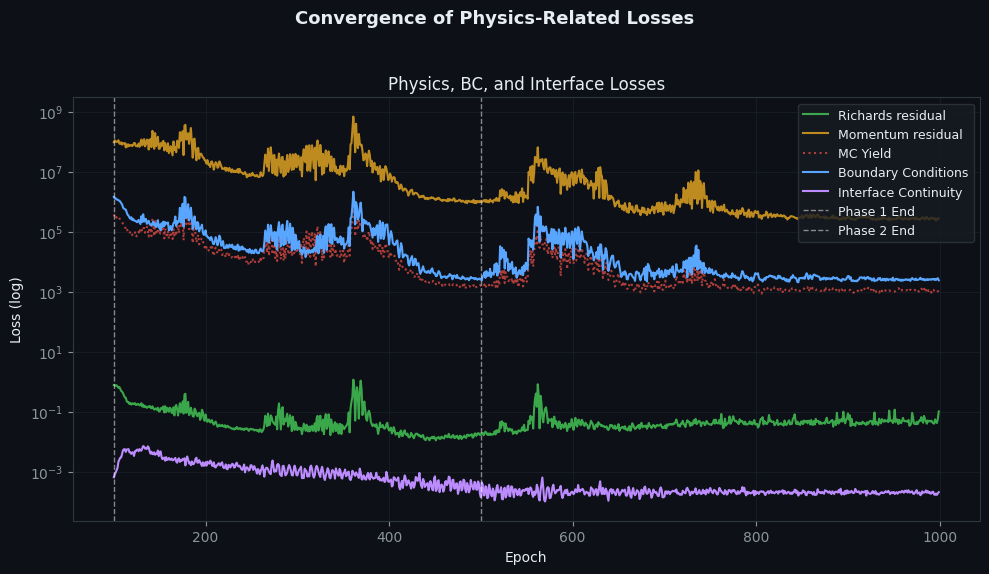

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Filter out None values which appear before physics losses are activated
ep2 = np.arange(PHASE1_END, PHASE3_END)
pr  = np.array([v for v in hist["phys_r"] if v is not None])
pm  = np.array([v for v in hist["phys_m"] if v is not None])
py  = np.array([v for v in hist["yield_"] if v is not None])
bc_arr  = np.array([v for v in hist["bc"] if v is not None])
if_arr  = np.array([v for v in hist["interface"] if v is not None])

fig, axes = plt.subplots(figsize=(10, 6))
fig.suptitle("Convergence of Physics-Related Losses", fontsize=13, fontweight="bold")

axes.semilogy(ep2, pr, color=C_GREEN, lw=1.5, label="Richards residual", alpha=0.9)
axes.semilogy(ep2, pm, color=C_YELLOW, lw=1.5, label="Momentum residual", alpha=0.9)
axes.semilogy(ep2, py, color=C_RED, lw=1.5, label="MC Yield", alpha=0.7, ls=":")
axes.semilogy(ep2, bc_arr, color=C_BLUE, lw=1.5, label="Boundary Conditions")
axes.semilogy(ep2, if_arr, color=C_PURPLE, lw=1.5, label="Interface Continuity")

axes.axvline(PHASE1_END, color="white", ls="--", lw=1, alpha=0.5, label="Phase 1 End")
axes.axvline(PHASE2_END, color="white", ls="--", lw=1, alpha=0.5, label="Phase 2 End")

axes.set_xlabel("Epoch")
axes.set_ylabel("Loss (log)")
axes.set_title("Physics, BC, and Interface Losses")
axes.legend(fontsize=9, loc='upper right')
axes.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("fig_physics_loss_convergence.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()